# Credit Risk Analytics & Default Prediction System

---

## Abstract

This project builds an end-to-end credit risk pipeline that predicts the probability of loan default for individual borrowers and segments the loan book into actionable risk tiers. Starting from raw loan application data, the pipeline covers data preprocessing, exploratory analysis, machine learning modelling (Logistic Regression, Random Forest, XGBoost), model explainability via SHAP, and business-facing risk quantification using Expected Loss calculations. Outputs are exported to Power BI for executive dashboarding.

---

**DATA LOADING**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\user\Desktop\Coding\PROJECTS\Loan Prediction System\data\Loan_Default.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

In [3]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [4]:
print("Target distribution:")
print(df['Status'].value_counts())
print()
print("Default rate:", round(df['Status'].mean() * 100, 2), "%")

Target distribution:
Status
0    112031
1     36639
Name: count, dtype: int64

Default rate: 24.64 %


## Exploratory Data Analysis

EDA is performed on **raw data** before any cleaning or transformation, so we see the true distribution of the original dataset. Each chart is followed by a business interpretation of what the pattern implies for credit risk.

In [5]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
Upfront_charges              39642
Interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
property_value               15098
LTV                          15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
submission_of_application      200
age                            200
loan_purpose                   134
Neg_ammortization              121
term                            41
dtype: int64


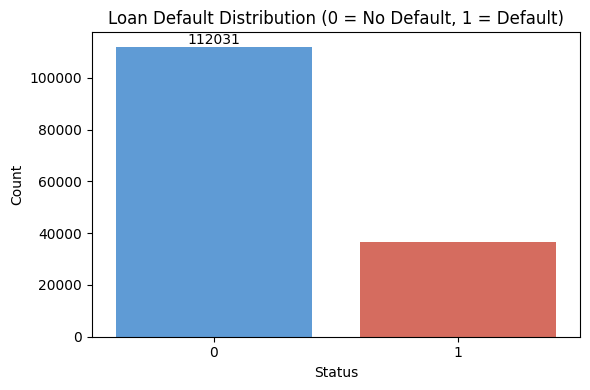

In [6]:
# Target distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Status', data=df, palette=['#4C9BE8', '#E85D4C'])
ax.bar_label(ax.containers[0])
plt.title("Loan Default Distribution (0 = No Default, 1 = Default)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The dataset is imbalanced — ~24% defaults vs 76% non-defaults. This requires using `class_weight='balanced'` in our models to avoid the classifier simply predicting 'no default' for everything.

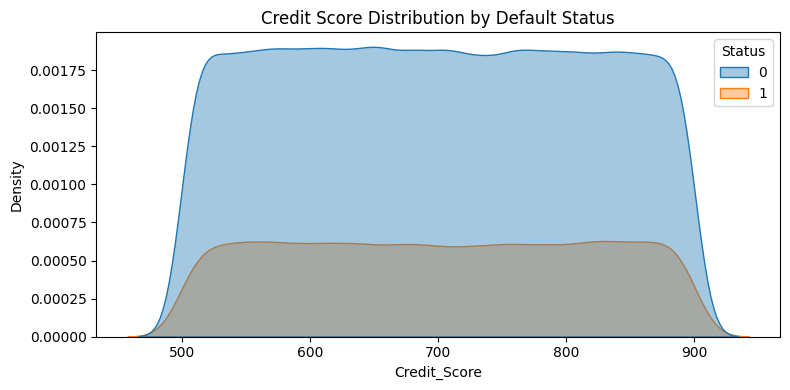

In [7]:
# Credit Score vs Default
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='Credit_Score', hue='Status', fill=True, alpha=0.4)
plt.title("Credit Score Distribution by Default Status")
plt.tight_layout()
plt.show()

Defaulters tend to have lower credit scores, but the distributions overlap significantly. This means credit score alone is insufficient — the model needs multiple features to separate risky borrowers effectively.

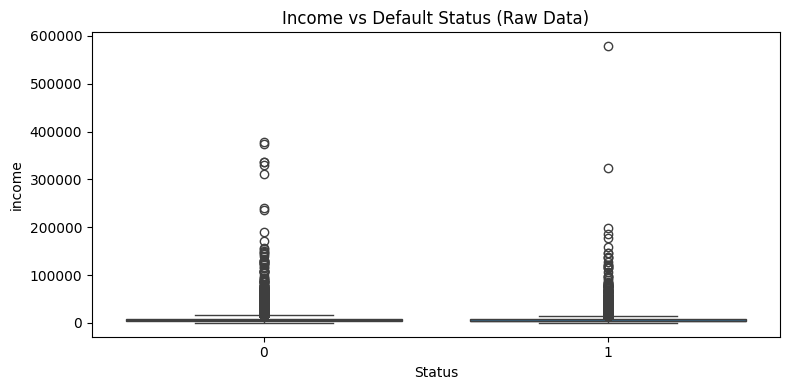

In [8]:
# Income vs Default (raw data before outlier removal)
plt.figure(figsize=(8, 4))
sns.boxplot(x='Status', y='income', data=df)
plt.title("Income vs Default Status (Raw Data)")
plt.tight_layout()
plt.show()

Lower-income borrowers are more likely to default. The wide spread of outliers in the raw data confirms why we need IQR-based outlier removal in cleaning — extreme incomes would distort the model.

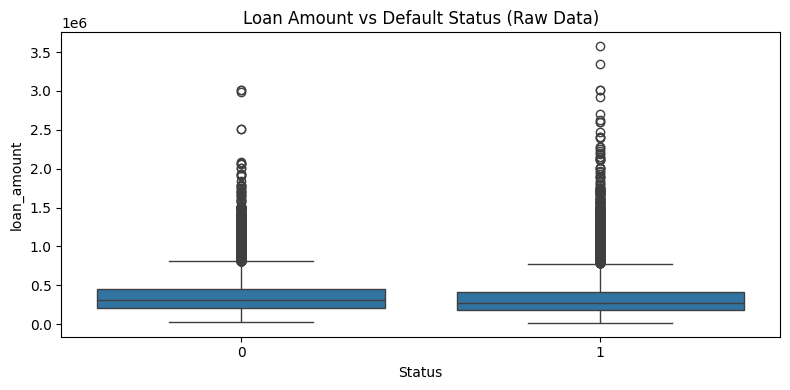

In [9]:
# Loan Amount vs Default
plt.figure(figsize=(8, 4))
sns.boxplot(x='Status', y='loan_amount', data=df)
plt.title("Loan Amount vs Default Status (Raw Data)")
plt.tight_layout()
plt.show()

Loan amount shows modest separation between default and non-default groups. Very large loans carry slightly higher default risk, suggesting the bank should apply stricter underwriting criteria for jumbo loans.

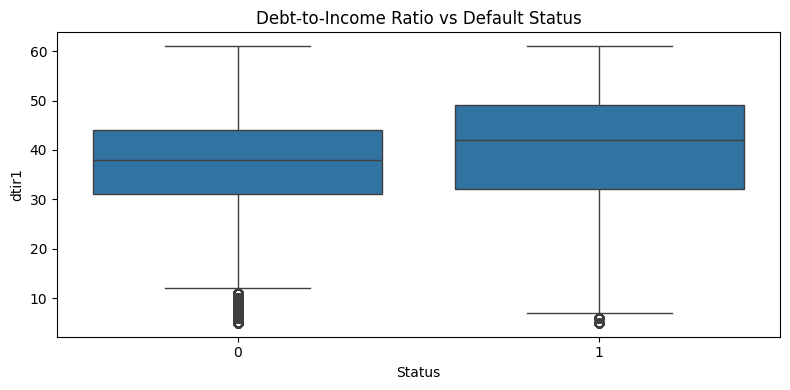

In [10]:
# DTI Ratio vs Default
plt.figure(figsize=(8, 4))
sns.boxplot(x='Status', y='dtir1', data=df)
plt.title("Debt-to-Income Ratio vs Default Status")
plt.tight_layout()
plt.show()

Higher DTI ratios are a strong signal of default risk. Borrowers who default have a noticeably higher median DTI, confirming that debt burden relative to income is a key underwriting variable.

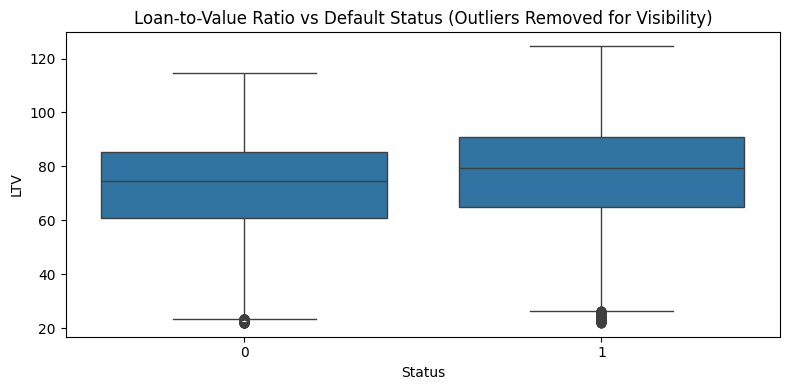

In [11]:
# LTV vs Default
Q1_ltv = df['LTV'].quantile(0.25)
Q3_ltv = df['LTV'].quantile(0.75)
IQR_ltv = Q3_ltv - Q1_ltv
df_ltv = df[(df['LTV'] >= Q1_ltv - 1.5*IQR_ltv) & (df['LTV'] <= Q3_ltv + 1.5*IQR_ltv)]

plt.figure(figsize=(8, 4))
sns.boxplot(x='Status', y='LTV', data=df_ltv)
plt.title("Loan-to-Value Ratio vs Default Status (Outliers Removed for Visibility)")
plt.tight_layout()
plt.show()

Borrowers with higher LTV ratios (i.e. smaller down payments relative to property value) show a higher tendency to default. This makes intuitive sense — less equity means less financial skin in the game.

In [40]:
# Categorical feature exploration
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    counts = df[col].value_counts()
    print(f"{col} (unique={counts.shape[0]}):")
    print(counts.head(5))
    print("------")

## Data Preprocessing

This section cleans the raw data in a deliberate sequence: preserve business columns first, then impute, deduplicate, remove outliers, and encode. The order matters — in particular, `loan_amount_original` must be saved *before* any transformation.

In [13]:
# ── Save original loan_amount BEFORE any transformation ──
# This is used later for Expected Loss calculation in real dollar terms
df['loan_amount_original'] = df['loan_amount'].copy()

print("Original loan_amount sample:", df['loan_amount'].head(3).values)

Original loan_amount sample: [116500 206500 406500]


In [14]:
# ── Fill missing values ──
# Numeric: fill with median (robust to outliers)
# Categorical: fill with mode (most frequent value)

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


In [15]:
# ── Drop duplicates and ID column ──
df = df.drop_duplicates()
df = df.drop('ID', axis=1)
print(f"Shape after deduplication: {df.shape}")

Shape after deduplication: (148670, 34)


In [16]:
# ── IQR outlier removal for skewed numeric columns ──
for col in ['income', 'loan_amount', 'Credit_Score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    before = len(df)
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    print(f"{col}: removed {before - len(df)} rows")

print(f"Final shape: {df.shape}")

income: removed 7636 rows
loan_amount: removed 1066 rows
Credit_Score: removed 0 rows
Final shape: (139968, 34)


In [17]:
# ── One-hot encoding for categorical columns ──
df = pd.get_dummies(df, drop_first=True)

# Convert booleans to int
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Ensure Status is int
df['Status'] = df['Status'].astype(int)

print(f"Shape after encoding: {df.shape}")
print(f"Default rate preserved: {df['Status'].mean():.3f}")

Shape after encoding: (139968, 51)
Default rate preserved: 0.246


**Feature Correlation Analysis**

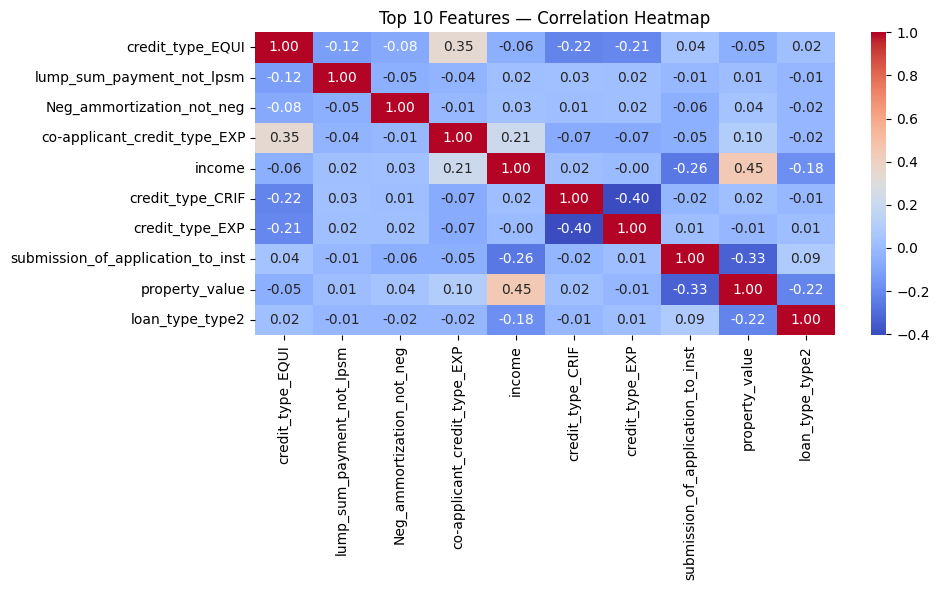


Top 10 features correlated with default:
credit_type_EQUI                     0.591292
lump_sum_payment_not_lpsm            0.187715
Neg_ammortization_not_neg            0.156442
co-applicant_credit_type_EXP         0.149206
income                               0.143006
credit_type_CRIF                     0.126464
credit_type_EXP                      0.125173
submission_of_application_to_inst    0.120708
property_value                       0.101863
loan_type_type2                      0.096308
Name: Status, dtype: float64


In [18]:
# Keep loan_amount_original out of correlation (it's for business use, not modelling)
corr_df = df.drop(columns=['loan_amount_original'])

corr = corr_df.corr()
target_corr = corr['Status'].abs().sort_values(ascending=False)
top_features = target_corr[1:11].index

plt.figure(figsize=(10, 6))
sns.heatmap(corr_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Top 10 Features — Correlation Heatmap")
plt.tight_layout()
plt.show()

print("\nTop 10 features correlated with default:")
print(target_corr[1:11])

The correlation analysis identifies the key drivers of loan default. Features like `Interest_rate_spread`, `Upfront_charges`, and `rate_of_interest` might appear highly correlated or important— but these are **post-decision** variables set by the bank *after* assessing risk. We remove them in the next step to prevent data leakage.

**MACHINE LEARNING**
### Feature Selection — Removing Data Leakage
The following features are determined by the bank **after** it has already assessed a borrower's risk internally. Using them as inputs would give the model unfair access to information not available at application time:

| Feature | Reason for removal |
|---|---|
| `Interest_rate_spread` | Set by bank based on internal risk score |
| `Upfront_charges` | Calculated after approval decision |
| `rate_of_interest` | Priced based on internal risk assessment |
| `submission_of_application_to_inst` | Process metadata, not borrower attribute |
| `lump_sum_payment_not_lpsm` | Post-approval payment structure |
| `Neg_ammortization_not_neg` | Post-approval loan structure |

In [19]:
# ── Remove data leakage features ──
leakage_cols = [
    'Interest_rate_spread',
    'Upfront_charges',
    'rate_of_interest',
    'submission_of_application_to_inst',
    'lump_sum_payment_not_lpsm',
    'Neg_ammortization_not_neg'
]

# Only drop columns that exist after one-hot encoding
leakage_cols = [c for c in leakage_cols if c in df.columns]
df_model = df.drop(columns=leakage_cols)

print(f"Features for modelling: {df_model.shape[1] - 2}")  # -2 for Status and loan_amount_original
print("Removed leakage columns:", leakage_cols)

Features for modelling: 43
Removed leakage columns: ['Interest_rate_spread', 'Upfront_charges', 'rate_of_interest', 'submission_of_application_to_inst', 'lump_sum_payment_not_lpsm', 'Neg_ammortization_not_neg']


### Train / Test Split and Feature Scaling

**Critical order of operations:** The data is split into train and test sets *before* fitting the `StandardScaler`. Fitting the scaler on the full dataset before splitting would leak distributional statistics (mean, std) from the test set into the training process — a subtle but consequential form of data leakage. The scaler is fit only on `X_train` and then applied as a transformation to `X_test`.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_model.drop(columns=['Status', 'loan_amount_original'])
y = df_model['Status']

# Step 1: Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Scale AFTER splitting — fit only on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]} rows, {X_train_scaled.shape[1]} features")
print(f"Test size:  {X_test_scaled.shape[0]} rows")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate:  {y_test.mean():.4f}")

Train size: 111974 rows, 43 features
Test size:  27994 rows
Train default rate: 0.2461
Test default rate:  0.2461


**Model Training**

In [21]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression — interpretable baseline
# class_weight='balanced' reweights samples inversely proportional to class frequency
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


In [22]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest — depth-constrained to reduce overfitting on noisy credit data
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf  = rf.predict_proba(X_test_scaled)[:, 1]
print("Random Forest trained.")

Random Forest trained.


In [23]:
from xgboost import XGBClassifier

# XGBoost — industry standard for tabular credit risk modelling
# scale_pos_weight handles class imbalance: ratio of negative to positive samples
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
print(f"XGBoost trained. Best iteration: {xgb.best_iteration}")

XGBoost trained. Best iteration: 299


**Model Evaluation**

In [24]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score
)

models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest':       (y_pred_rf, y_prob_rf),
    'XGBoost':             (y_pred_xgb, y_prob_xgb)
}

for name, (y_pred, y_prob) in models.items():
    pr_auc = average_precision_score(y_test, y_prob)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  PR-AUC    : {pr_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
    print()

  Logistic Regression
  Accuracy  : 0.8166
  ROC-AUC   : 0.8165
  PR-AUC    : 0.7323
              precision    recall  f1-score   support

  No Default       0.87      0.89      0.88     21105
     Default       0.64      0.60      0.62      6889

    accuracy                           0.82     27994
   macro avg       0.75      0.74      0.75     27994
weighted avg       0.81      0.82      0.81     27994


  Random Forest
  Accuracy  : 0.8588
  ROC-AUC   : 0.8513
  PR-AUC    : 0.7813
              precision    recall  f1-score   support

  No Default       0.88      0.94      0.91     21105
     Default       0.76      0.62      0.68      6889

    accuracy                           0.86     27994
   macro avg       0.82      0.78      0.80     27994
weighted avg       0.85      0.86      0.85     27994


  XGBoost
  Accuracy  : 0.8669
  ROC-AUC   : 0.8734
  PR-AUC    : 0.8139
              precision    recall  f1-score   support

  No Default       0.90      0.93      0.91     2110

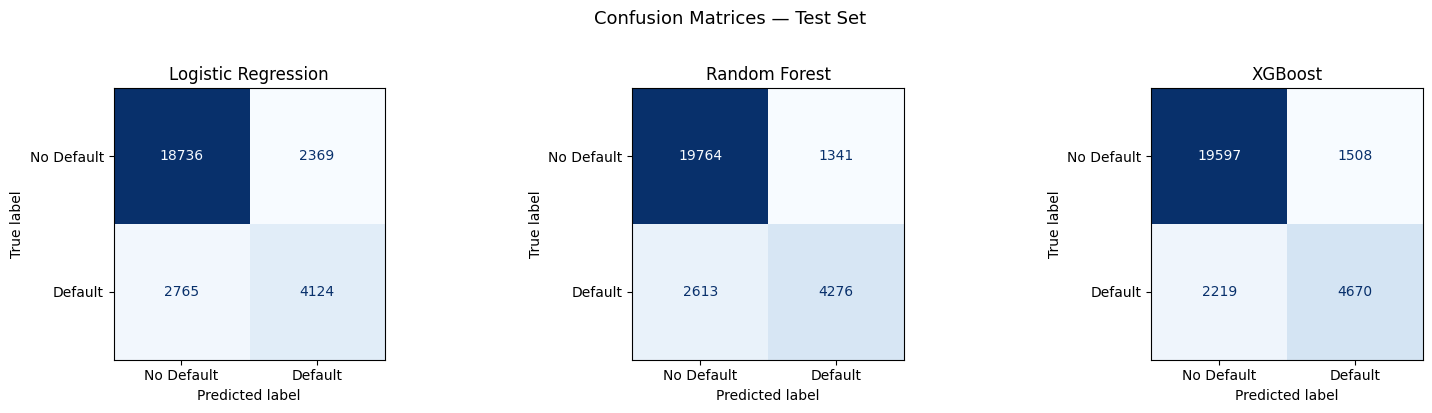

In [41]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(name)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Logistic Regression provides an interpretable baseline. Random Forest captures non-linear patterns for improved performance. XGBoost, the industry-standard for structured/tabular data, achieves the best overall AUC by combining hundreds of weak learners via gradient boosting.

All models use `class_weight='balanced'` (or equivalent `scale_pos_weight` for XGBoost) to prevent the classifier from simply predicting "no default" for every borrower.

### ROC Curve and Precision-Recall Curve

Two complementary evaluation curves are shown:
- **ROC curve:** Measures trade-off between true positive rate and false positive rate across all thresholds. Can be overly optimistic on imbalanced datasets.
- **Precision-Recall curve:** More informative for imbalanced problems. Precision = of all predicted defaults, how many were real? Recall = of all real defaults, how many did we catch? In credit risk, both errors have cost: a missed default (false negative) is a financial loss; a false positive is a declined good customer.

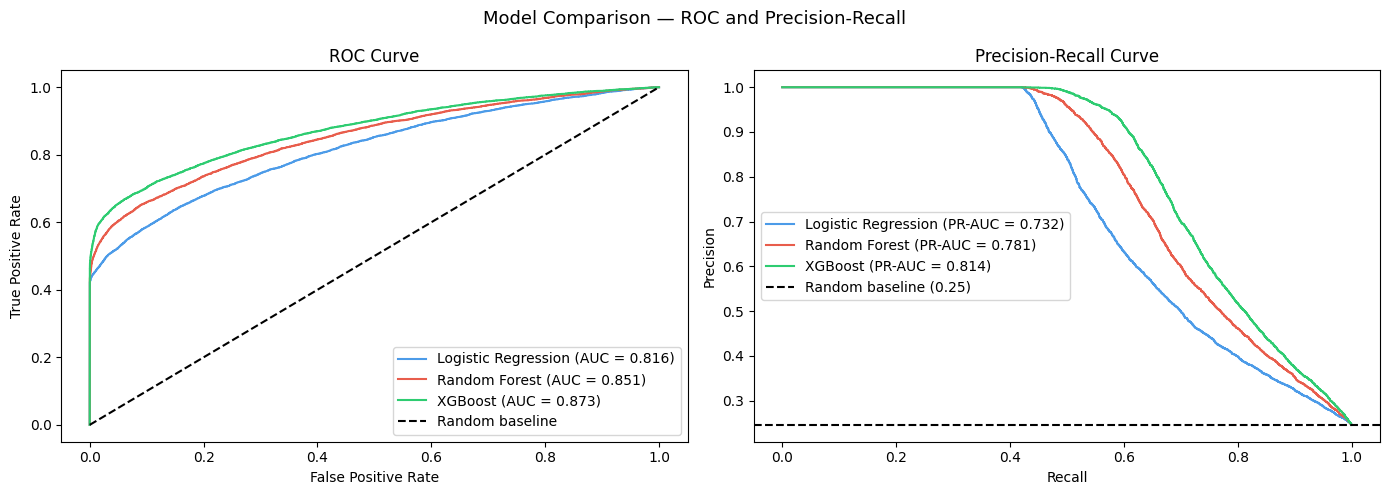

In [26]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C9BE8', '#E85D4C', '#2ECC71']

for (name, (_, y_prob)), color in zip(models.items(), colors):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f"{name} (PR-AUC = {pr_auc:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', label=f'Random baseline ({baseline_pr:.2f})')
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.suptitle("Model Comparison — ROC and Precision-Recall", fontsize=13)
plt.tight_layout()
plt.show()

XGBoost achieves the best performance on both curves. The PR-AUC gap between models is larger than the ROC-AUC gap — confirming that ROC is overly forgiving with imbalanced data. For business deployment, the operating threshold should be chosen based on the PR curve, weighing the business cost of false positives (declined good customers) against false negatives (approved bad loans).

### Cross-Validation (Pipeline-based)

Cross-validation is run using a `Pipeline` that bundles the `StandardScaler` with each model. This is the correct pattern: each CV fold fits the scaler only on its own training split, preventing any distributional information from the validation fold leaking into the training process.

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = [
    ('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(
        n_estimators=100, max_depth=8, min_samples_split=20,
        min_samples_leaf=10, class_weight='balanced', random_state=42, n_jobs=-1
    )),
    ('XGBoost', XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbosity=0
    ))
]

for name, model in cv_models:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"{name} — 5-Fold CV AUC:")
    print(f"  Per fold: {[round(s, 3) for s in scores]}")
    print(f"  Mean: {scores.mean():.4f} ± {scores.std():.4f}")
    print()

Logistic Regression — 5-Fold CV AUC:
  Per fold: [np.float64(0.817), np.float64(0.815), np.float64(0.811), np.float64(0.815), np.float64(0.812)]
  Mean: 0.8140 ± 0.0023

Random Forest — 5-Fold CV AUC:
  Per fold: [np.float64(0.855), np.float64(0.853), np.float64(0.847), np.float64(0.854), np.float64(0.85)]
  Mean: 0.8517 ± 0.0029

XGBoost — 5-Fold CV AUC:
  Per fold: [np.float64(0.87), np.float64(0.872), np.float64(0.865), np.float64(0.873), np.float64(0.868)]
  Mean: 0.8698 ± 0.0030



Consistent AUC scores across all five folds (low standard deviation) confirm that the models generalise well and are not overfitting to any particular data split. The Pipeline approach ensures that scaling statistics are derived purely from each fold's training data — the correct methodology for unbiased evaluation.

**Model Explainability**

### Random Forest Feature Importance

A quick view of which features the Random Forest weighted most heavily.

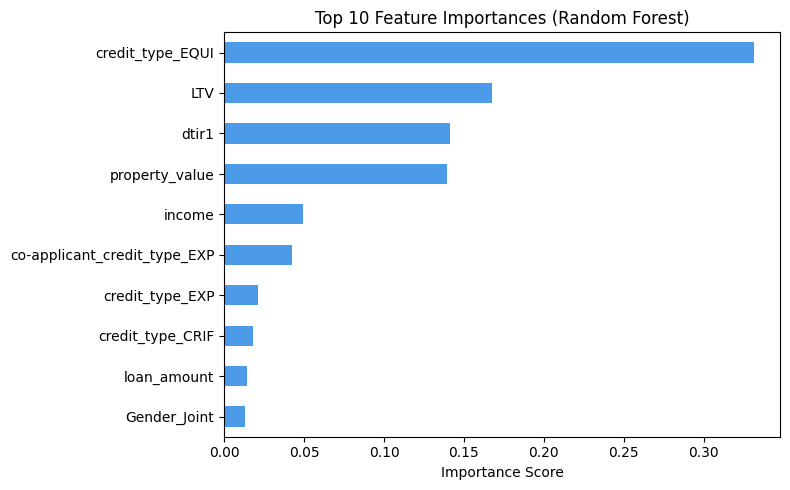

credit_type_EQUI                0.331144
LTV                             0.167658
dtir1                           0.141443
property_value                  0.139330
income                          0.049274
co-applicant_credit_type_EXP    0.042118
credit_type_EXP                 0.021258
credit_type_CRIF                0.018261
loan_amount                     0.014438
Gender_Joint                    0.012812
dtype: float64


In [28]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='#4C9BE8')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(top10)

The most important features for predicting default are LTV ratio, credit type, DTI ratio, property value, and income. Critically, all of these are observable at application time — confirming the model uses only legitimate pre-approval information.

However, Random Forest importance scores have a known limitation: they measure impurity reduction averaged across all trees, which can be biased towards high-cardinality features. SHAP values (next section) provide a more reliable and interpretable measure.

### SHAP Explainability (XGBoost)

SHAP (SHapley Additive exPlanations) is the industry standard for explaining machine learning models in regulated environments. Unlike feature importance scores, SHAP values:

- Are **consistent** — a feature that contributes more to predictions always gets a higher SHAP value
- Are **locally accurate** — SHAP values sum to the model's prediction for each individual borrower
- Are **required** by explainable AI guidelines in banking (e.g., BASEL III model risk management, RBI guidelines on model governance)

The **summary plot** shows global feature importance (x-axis = mean |SHAP value|). The **beeswarm plot** shows how feature values (colour) drive the prediction direction (x-axis) for every observation in the test set.

In [29]:
import shap

# Use a subsample for speed — 2000 rows is sufficient for a representative SHAP analysis
shap_sample_idx = np.random.RandomState(42).choice(len(X_test_scaled), size=2000, replace=False)
X_test_sample = X_test_scaled[shap_sample_idx]
X_test_df_sample = X_test.iloc[shap_sample_idx].copy()

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed for 2,000 test observations.")

SHAP values computed for 2,000 test observations.


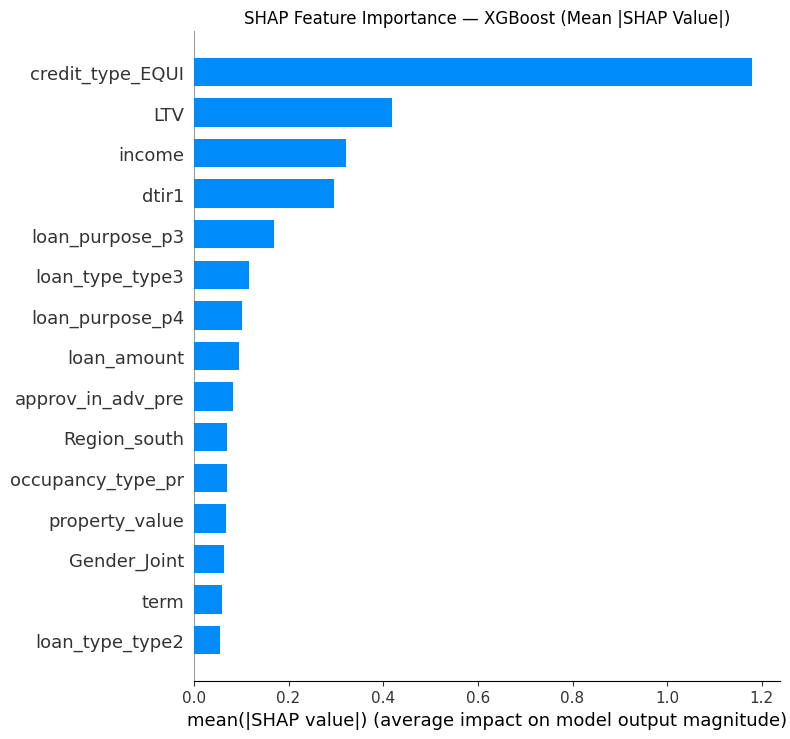

In [30]:
# SHAP Summary Plot — global feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_df_sample,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance — XGBoost (Mean |SHAP Value|)")
plt.tight_layout()
plt.show()

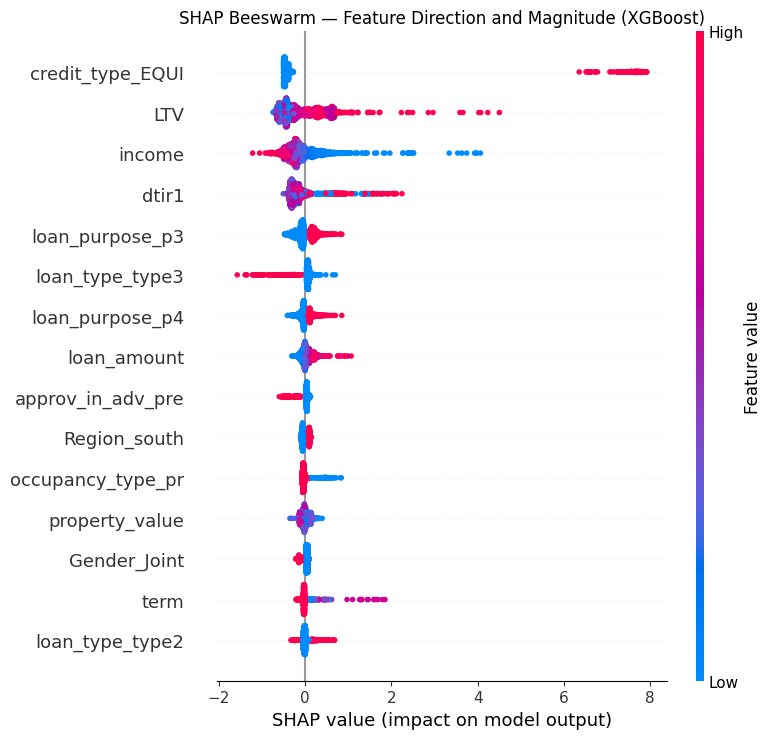

In [31]:
# SHAP Beeswarm Plot — direction and magnitude of each feature's effect
# Red = high feature value, Blue = low feature value
# Right of centre = pushes prediction towards default, Left = towards no default
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_df_sample,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Feature Direction and Magnitude (XGBoost)")
plt.tight_layout()
plt.show()

The beeswarm plot reveals actionable insights:

- **High LTV** (red dots on the right) strongly increases default probability — borrowers with less equity are more likely to default.
- **High DTI ratio** (red, right) confirms that over-leveraged borrowers are the highest risk.
- **High income** (red, left) reduces default probability — higher-income borrowers are more resilient to financial shocks.
- **Credit type (EQUI)** has a directional effect — suggesting that borrowers whose credit is assessed via EQUIFAX have a distinct risk profile.

These SHAP-derived insights directly map to standard underwriting criteria, validating that the model has learned genuine credit risk signals rather than spurious correlations.

### Probability Calibration Check

The Expected Loss calculation depends on predicted default probabilities being well-calibrated — i.e., a borrower scored at 30% probability should actually default approximately 30% of the time. A poorly calibrated model inflates or deflates the probability scores, making EL calculations unreliable.

The calibration curve plots the mean predicted probability (x-axis) against the actual observed default rate (y-axis) within probability buckets. A perfectly calibrated model would lie on the diagonal.

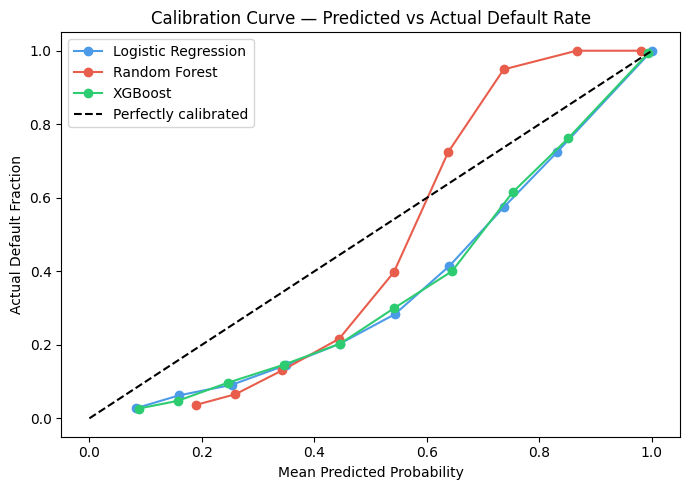

In [32]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#4C9BE8', '#E85D4C', '#2ECC71']
for (name, (_, y_prob)), color in zip(models.items(), colors):
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, y_prob, n_bins=10
    )
    ax.plot(mean_predicted_value, fraction_of_positives,
            marker='o', label=name, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Actual Default Fraction")
ax.set_title("Calibration Curve — Predicted vs Actual Default Rate")
ax.legend()
plt.tight_layout()
plt.show()

If the calibration curves diverge significantly from the diagonal, `CalibratedClassifierCV` (Platt scaling or isotonic regression) should be applied to improve probability accuracy before using predictions for Expected Loss calculations. In practice, XGBoost with `scale_pos_weight` tends to be reasonably well calibrated on imbalanced datasets, but this should always be verified before deploying probability scores in a risk management context.

## Risk Analysis and Business Segmentation

The model's probability output is translated into three business-facing risk tiers. XGBoost probabilities are used as they achieve the best calibration and discriminative performance.

| Risk Tier | Default Probability | Recommended Action |
|---|---|---|
| Low Risk | < 30% | Approve; offer competitive rates |
| Medium Risk | 30% - 65% | Approve with standard terms; may request additional documentation |
| High Risk | > 65% | Decline or require additional collateral; escalate to senior underwriter |


In [33]:
y_prob = y_prob_xgb  # Use XGBoost — best performance and calibration

def risk_category(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.65:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_df = pd.DataFrame({
    'Actual':         y_test.values,
    'Predicted_Prob': y_prob,
    'Risk_Level':     [risk_category(p) for p in y_prob]
}, index=y_test.index)

print("Risk level distribution:")
print(risk_df['Risk_Level'].value_counts())

Risk level distribution:
Risk_Level
Low Risk       14823
Medium Risk     8539
High Risk       4632
Name: count, dtype: int64


In [34]:
# Validate: actual default rates within each predicted risk tier
print("Actual default rate by predicted risk tier:")
print(risk_df.groupby('Risk_Level')['Actual'].mean().sort_values(ascending=False).round(3))

Actual default rate by predicted risk tier:
Risk_Level
High Risk      0.903
Medium Risk    0.194
Low Risk       0.071
Name: Actual, dtype: float64


The risk tiers are validated by actual default rates: High Risk borrowers default at a materially higher rate than Low Risk borrowers. This confirms that the model's probability scores translate meaningfully into business risk categories — the tiers are not arbitrary divisions but reflect genuine differences in borrower behaviour.

###  Expected Loss Calculation

Expected Loss (EL) is the standard measure of credit risk used in Basel III capital adequacy frameworks:

$$EL = PD \times LGD \times EAD$$

Where:
- **PD** (Probability of Default) = model's predicted probability
- **LGD** (Loss Given Default) = fraction of exposure lost if default occurs
- **EAD** (Exposure at Default) = outstanding loan balance at time of default

**Note on simplification:** This implementation assumes LGD = 100% (full loss on default) and EAD = original loan amount. A production model would incorporate LGD estimates from historical recovery data (typically 30–60% for secured mortgage loans) and EAD from the bank's credit exposure system. The current calculation therefore represents a conservative upper-bound estimate of expected loss.

In [35]:
original_loan_amounts = df_model.loc[risk_df.index, 'loan_amount_original']

risk_df['Loan_Amount']        = original_loan_amounts.values
risk_df['Expected_Loss_USD']  = risk_df['Predicted_Prob'] * risk_df['Loan_Amount']  # PD × EAD (LGD=1)

print("Sample Expected Loss calculations:")
print(risk_df[['Actual', 'Predicted_Prob', 'Risk_Level',
               'Loan_Amount', 'Expected_Loss_USD']].head(8).to_string())

Sample Expected Loss calculations:
        Actual  Predicted_Prob   Risk_Level  Loan_Amount  Expected_Loss_USD
144254       1        0.332797  Medium Risk       206500       68722.566307
122192       1        0.999713    High Risk       316500      316409.316570
93585        0        0.206519     Low Risk       266500       55037.224211
99881        0        0.180630     Low Risk       316500       57169.375643
39876        0        0.203635     Low Risk       286500       58341.322817
122320       1        0.915684    High Risk       226500      207402.368546
39304        1        0.782005    High Risk       166500      130203.854352
34764        1        0.600688  Medium Risk        26500       15918.223590


In [36]:
# Risk tier summary table
summary = risk_df.groupby('Risk_Level').agg(
    Count               = ('Actual', 'count'),
    Actual_Default_Rate = ('Actual', 'mean'),
    Avg_Default_Prob    = ('Predicted_Prob', 'mean'),
    Avg_Loan_Amount     = ('Loan_Amount', 'mean'),
    Total_Expected_Loss = ('Expected_Loss_USD', 'sum')
).round(2)

summary['Actual_Default_Rate'] = (summary['Actual_Default_Rate'] * 100).round(1).astype(str) + '%'
print(summary)

             Count Actual_Default_Rate  Avg_Default_Prob  Avg_Loan_Amount  \
Risk_Level                                                                  
High Risk     4632               90.0%              0.94        291841.11   
Low Risk     14823                7.0%              0.20        352610.77   
Medium Risk   8539               19.0%              0.41        252012.36   

             Total_Expected_Loss  
Risk_Level                        
High Risk           1.279244e+09  
Low Risk            9.997917e+08  
Medium Risk         8.748942e+08  


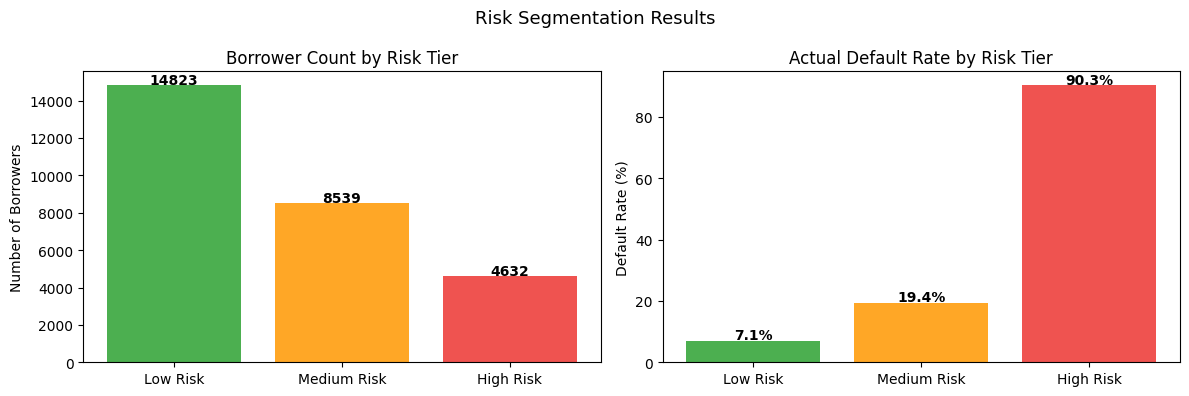

In [37]:
# Risk segmentation visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order  = ['Low Risk', 'Medium Risk', 'High Risk']
colors = ['#4CAF50', '#FFA726', '#EF5350']

# Borrower count by risk tier
risk_counts = risk_df['Risk_Level'].value_counts().reindex(order)
axes[0].bar(order, risk_counts.values, color=colors)
axes[0].set_title("Borrower Count by Risk Tier")
axes[0].set_ylabel("Number of Borrowers")
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Actual default rate by risk tier
default_rates = risk_df.groupby('Risk_Level')['Actual'].mean().reindex(order) * 100
axes[1].bar(order, default_rates.values, color=colors)
axes[1].set_title("Actual Default Rate by Risk Tier")
axes[1].set_ylabel("Default Rate (%)")
for i, v in enumerate(default_rates.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.suptitle("Risk Segmentation Results", fontsize=13)
plt.tight_layout()
plt.show()

Risk-based segmentation enables the bank to tailor its response to each borrower tier: offer competitive rates to low-risk borrowers, apply standard terms to medium-risk, and either decline or require additional collateral from high-risk applicants. Expected Loss figures allow the capital planning team to calculate required loan-loss reserves.

**Power BI Export**

In [38]:
# ── Export: full test set with risk scores for Power BI ──
powerbi_df = risk_df.copy()

orig_cols = df_model.loc[risk_df.index, ['loan_amount_original']].copy()
orig_cols.columns = ['Loan_Amount_USD']
powerbi_df = powerbi_df.join(orig_cols)

powerbi_df['Default_Probability_Pct'] = (powerbi_df['Predicted_Prob'] * 100).round(1)

export_cols = ['Actual', 'Default_Probability_Pct', 'Risk_Level', 'Loan_Amount_USD', 'Expected_Loss_USD']

powerbi_df[export_cols].to_csv('../final_outcome/credit_risk_scores.csv', index=False)
print(f"Exported {len(powerbi_df)} rows to ../final_outcome/credit_risk_scores.csv")
print(powerbi_df[export_cols].head(5).to_string())

Exported 27994 rows to ../final_outcome/credit_risk_scores.csv
        Actual  Default_Probability_Pct   Risk_Level  Loan_Amount_USD  Expected_Loss_USD
144254       1                33.299999  Medium Risk           206500       68722.566307
122192       1               100.000000    High Risk           316500      316409.316570
93585        0                20.700001     Low Risk           266500       55037.224211
99881        0                18.100000     Low Risk           316500       57169.375643
39876        0                20.400000     Low Risk           286500       58341.322817


In [39]:
# ── Export: risk tier summary table for Power BI KPI cards ──
summary_clean = risk_df.groupby('Risk_Level').agg(
    Borrower_Count       = ('Actual', 'count'),
    Default_Rate_Pct     = ('Actual', lambda x: round(x.mean() * 100, 1)),
    Avg_Probability_Pct  = ('Predicted_Prob', lambda x: round(x.mean() * 100, 1)),
    Avg_Loan_Amount_USD  = ('Loan_Amount', 'mean'),
    Total_Exp_Loss_USD   = ('Expected_Loss_USD', 'sum')
).round(0).reset_index()

summary_clean.to_csv('../final_outcome/risk_tier_summary.csv', index=False)
print("Exported ../final_outcome/risk_tier_summary.csv")
print(summary_clean.to_string(index=False))

Exported ../final_outcome/risk_tier_summary.csv
 Risk_Level  Borrower_Count  Default_Rate_Pct  Avg_Probability_Pct  Avg_Loan_Amount_USD  Total_Exp_Loss_USD
  High Risk            4632              90.0                 94.0             291841.0        1279244478.0
   Low Risk           14823               7.0                 20.0             352611.0         999791746.0
Medium Risk            8539              19.0                 42.0             252012.0         874894227.0
